# **Overconfidence of Q-learning agents in noisy signals in a voting environment**

**Modifications:**

1.  **`qi` unrevealed**: the agent only has access to its signal `si ∈ {0, 1}`, not its actual precision `qi`.

2.  **Belief Q-matrix**: a secondary Q-table `Q_belief[si, action_belief]` learns to form a belief `q̂i` from the signal `si`. The learned belief becomes the state for the main Q-table.

**Two Q-tables architecture:**
-   `Q_belief[si, j]`: learns which `q̂i` value to use given `si`
-   `Q_main[q̂i_idx, λ_idx]`: learns which `λ` to choose given the belief `q̂i`

### 1. Import Packages

In [ ]:
import numpy as np
import random
import math
import matplotlib.pyplot as plt
from copy import deepcopy

np.random.seed(1234)

### 2. Model Parameters

In [ ]:
m = 10
Q_VALUES = np.linspace(0.1, 0.9, m)   # qi space (not observed by the agent)

# Actions : choose lambda

LAMBDA_O = 1.3   # overconfident
LAMBDA_N = 1.0   # neutral
LAMBDA_U = 0.7   # underconfident
LAMBDAS  = [LAMBDA_O, LAMBDA_N, LAMBDA_U]
LAMBDA_NAMES = ['Overconfident (λ=1.3)', 'Neutral (λ=1.0)', 'Underconfident (λ=0.7)']

# The agent's observable state is only the received signal.

signal_space = 2         # si ∈ {0 (bad signal), 1 (good signal)}
action_space = len(LAMBDAS)  # 3 λ actions

# The agent also learns to estimate qi from si.
# Belief actions: choose an index from Q_VALUES as estimation q̂i.

belief_action_space = m  # the agent can choose from the m Q_VALUES

# No overconfidence penalty, an incorrect vote always gives reward = 0.

# Q-learning hyperparameters
alpha   = 0.15    # learning rate
delta   = 0.95    # discount factor
beta    = 4e-6    # epsilon-greedy decay rate

# Simulation
n_episodes      = 5
criterion_final = 500_000

print(f"Observable signal: si ∈ {{0, 1}}  (qi not revealed)")
print(f"λ action space: {action_space} → {LAMBDAS}")
print(f"Q_main  : {signal_space} x {action_space}  (signal x λ)")
print(f"Q_belief: {signal_space} x {belief_action_space}  (signal x estimated q̂i)")

Observable signal: si ∈ {0, 1}  (qi not revealed)
λ action space: 3 → [1.3, 1.0, 0.7]
Q_main  : 2 x 3  (signal x λ)
Q_belief: 2 x 10  (signal x estimated q̂i)


### 3. Fonctions du modèle

In [ ]:
def get_signal(qi, true_state):
    """The agent receives a correct signal with probability qi."""
    if random.random() < qi:
        return true_state
    else:
        return 1 - true_state


def decide_vote(pi_qi):
    """The agent votes if pi(qi) > 0.5."""
    return pi_qi > 0.5


def compute_reward(signal, lam, qi, true_state):
    """
    Individual reward (no penalty for a sub-optimal overconfident vote) :
    +1 if the agent votes and their signal matches the true state
     0 otherwise (abstention or wrong vote)
pi(qi) = lam*qi is limited to [0,1] to stay within probability interval.
    """
    pi_qi = min(lam * qi, 1.0)
    votes = decide_vote(pi_qi)

    if not votes:
        return 0.0   # abstention

    correct_vote = (signal == true_state)
    return 1.0 if correct_vote else 0.0


print("Model functions defined.")


Model functions defined.


### 4. Q-learning algorithm with two Q-tables

**Architecture :**

For each period `t` :
1. The agent receives the signal `si ∈ {0, 1}` which is the only observable information
2. **Q_belief** : the agent forms a belief such that `si`, `j` → `q̂i = Q_VALUES[j]`
3. **Q_main** : chooses `λ` based on `q̂i` (discretized)
4. The agent votes and receives a reward (without a penalty if overconfident and incorrect)
5. Both Q-tables are updated using the Bellman equation

In [ ]:
def q_learning_voter_belief(
    beta=4e-6, alpha=0.15, delta=0.95,
    n_episodes=5, criterion_final=500_000
):
    """
    Q-learning agent with :
    - signal qi not revealed
    - overconfident and incorrect vote without penalty
    - Q-matrix of beliefs
    """

    # --- initial Q-tables ---
    # Q_main[q̂i_idx, λ_idx] : voting strategy based on the belief
    q_main_init   = np.zeros((belief_action_space, action_space))
    # Q_belief[si, belief_action] : belief formation strategy
    q_belief_init = np.zeros((signal_space, belief_action_space))

    # --- Stock results ---
    lambda_info  = np.zeros((criterion_final, n_episodes), dtype=int)
    pi_info      = np.zeros((criterion_final, n_episodes))
    reward_info  = np.zeros((criterion_final, n_episodes))
    belief_info  = np.zeros((criterion_final, n_episodes))  # q̂i retained
    qhat_idx_info= np.zeros((criterion_final, n_episodes), dtype=int)
    true_qi_idx_info = np.zeros((criterion_final, n_episodes), dtype=int) # Store true qi index

    for ep in range(n_episodes):
        print(f"  Episode {ep+1}/{n_episodes}...")
        q_main   = deepcopy(q_main_init)
        q_belief = deepcopy(q_belief_init)

        # qi randomly drawn and unobservable by the agent
        qi_idx = random.randint(0, len(Q_VALUES) - 1)

        for t in range(criterion_final):

            # ε-greedy decreasing
            epsilon = math.exp(-beta * t)

            # qi not revealed
            # The agent forms an approximation of qi based on si

            qi         = Q_VALUES[qi_idx]
            true_state = random.randint(0, 1)
            si         = get_signal(qi, true_state)  # only observable info

            # Q_belief — choose q̂i based on si
            # The agent selects a belief action j, an index, which amounts to choosing, q̂i = Q_VALUES[j].

            if random.random() <= epsilon:
                belief_action = random.randint(0, belief_action_space - 1)
            else:
                belief_action = np.argmax(q_belief[si])

            q_hat = Q_VALUES[belief_action]   # estimated belief

            # Q_main — choose λ based on q̂i

            if random.random() <= epsilon:
                lam_action = random.randint(0, action_space - 1)
            else:
                lam_action = np.argmax(q_main[belief_action])

            lam   = LAMBDAS[lam_action]
            pi_qi = min(lam * q_hat, 1.0)  # final subjective belief

            # Reward : +1 if correct, 0 if not (no penalty)

            reward = compute_reward(si, lam, q_hat, true_state)

            # --- Save info ---
            lambda_info[t, ep]   = lam_action
            pi_info[t, ep]       = pi_qi
            reward_info[t, ep]   = reward
            belief_info[t, ep]   = q_hat
            qhat_idx_info[t, ep] = belief_action
            true_qi_idx_info[t, ep] = qi_idx # Store true qi index

            # --- Transition : new qi drawn randomly ---
            # We stay on the same qi with prob 0.8, change otherwise
            # (simulates persistence of an agent's competence)
            if random.random() < 0.8:
                next_qi_idx = qi_idx
            else:
                next_qi_idx = random.randint(0, len(Q_VALUES) - 1)

            # Next signal
            next_qi  = Q_VALUES[next_qi_idx]
            next_ts  = random.randint(0, 1)
            next_si  = get_signal(next_qi, next_ts)
            # Next optimal belief based on current Q_belief
            next_ba  = np.argmax(q_belief[next_si])

            # --- Q_main update ---
            q_main[belief_action, lam_action] = (
                (1 - alpha) * q_main[belief_action, lam_action]
                + alpha * (reward + delta * np.max(q_main[next_ba]))
            )

            # --- Q_belief update(Bellman) ---
            q_belief[si, belief_action] = (
                (1 - alpha) * q_belief[si, belief_action]
                + alpha * (reward + delta * np.max(q_belief[next_si]))
            )

            qi_idx = next_qi_idx

    print("\nSimulation completed.")
    return lambda_info, pi_info, reward_info, belief_info, qhat_idx_info, true_qi_idx_info

### 5. Launching the simulation

In [ ]:
print("Launching simulation...")
print(f"Parameters : alpha={alpha}, beta={beta}, delta={delta}")
print(f"             {n_episodes} episodes x {criterion_final} periods\n")

lambda_info, pi_info, reward_info, belief_info, qhat_idx_info, true_qi_idx_info = q_learning_voter_belief(
    beta=beta,
    alpha=alpha,
    delta=delta,
    n_episodes=n_episodes,
    criterion_final=criterion_final,
)

Launching simulation...
Parameters : alpha=0.15, beta=4e-06, delta=0.95
             5 episodes x 500000 periods

  Episode 1/5...
  Episode 2/5...
  Episode 3/5...
  Episode 4/5...
  Episode 5/5...

Simulation completed.


### 6. Visualizing results

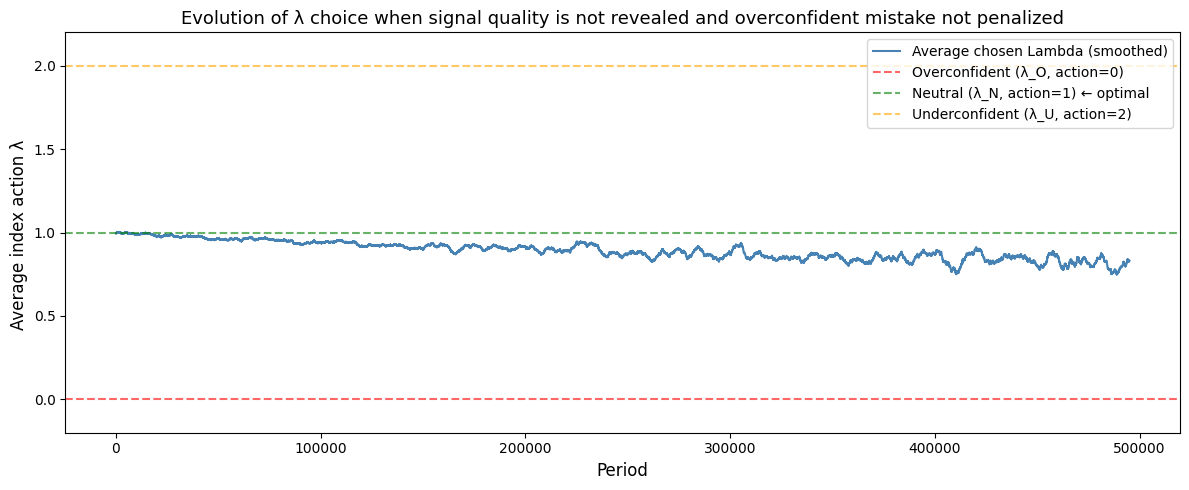

 Average final lambda : 0.8037
  0 = Overconfident | 1 = Neutre | 2 = Underconfident


In [ ]:
# Figure 1: Evolution of chosen lambda

smooth = 5000
avg_lambda = np.mean(lambda_info, axis=1)
smoothed   = np.convolve(avg_lambda, np.ones(smooth)/smooth, mode='valid')

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(smoothed, color='steelblue', lw=1.5, label='Average chosen Lambda (smoothed)')
ax.axhline(y=0, ls='--', color='red',   alpha=0.6, label='Overconfident (λ_O, action=0)')
ax.axhline(y=1, ls='--', color='green', alpha=0.6, label='Neutral (λ_N, action=1) ← optimal')
ax.axhline(y=2, ls='--', color='orange',alpha=0.6, label='Underconfident (λ_U, action=2)')
ax.set_xlabel('Period', fontsize=12)
ax.set_ylabel('Average index action λ ', fontsize=12)
ax.set_title('Evolution of λ choice when signal quality is not revealed and overconfident mistake not penalized', fontsize=13)
ax.legend(fontsize=10)
ax.set_ylim(-0.2, 2.2)
plt.tight_layout()
plt.show()
print(f" Average final lambda : {np.mean(lambda_info[-10000:]):.4f}")
print("  0 = Overconfident | 1 = Neutre | 2 = Underconfident")

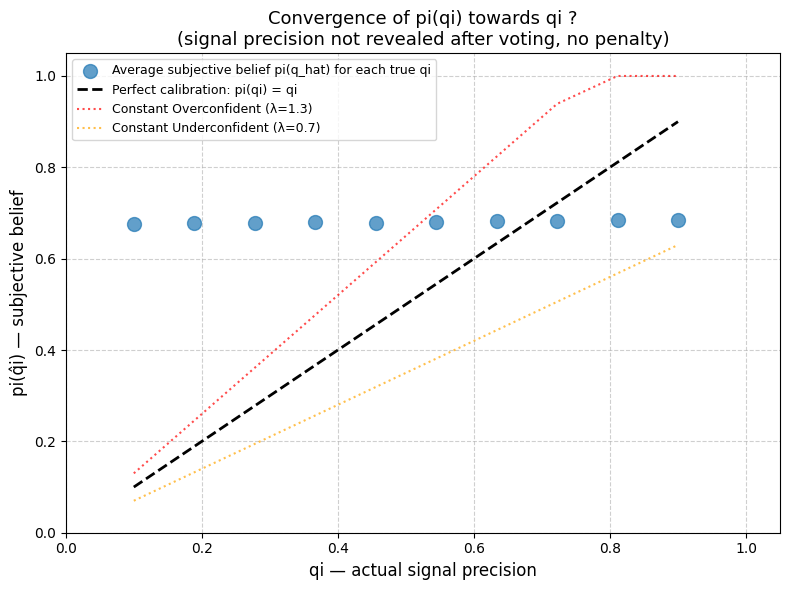

Average subjective belief (pi(q̂i)) at the end: 0.680
Average true qi: 0.500


In [ ]:
# Figure 2 : pi(q_hat) vs true qi — convergence of subjective belief
# This plot evaluates the agent's learned beliefs against the true underlying q_i.

# We'll use the last half of the simulation to assess convergence
T_half = criterion_final // 2

# Prepare data for plotting
# We retrieve the true qi values and the corresponding subjective beliefs (pi_qi)

# Flatten the arrays for easier processing
flat_true_qi_idx = true_qi_idx_info[T_half:].flatten()
flat_pi_info = pi_info[T_half:].flatten()

# Get the actual true qi values
flat_true_qi = Q_VALUES[flat_true_qi_idx]

# Calculate the average pi_qi for each true qi value
avg_pi_qi_per_true_qi = np.zeros(len(Q_VALUES))
for i, q_val in enumerate(Q_VALUES):
    # Find all instances where this true_qi_idx occurred
    mask = (flat_true_qi_idx == i)
    if np.any(mask):
        avg_pi_qi_per_true_qi[i] = np.mean(flat_pi_info[mask])
    else:
        avg_pi_qi_per_true_qi[i] = np.nan # Handle cases where a qi might not have appeared

fig, ax = plt.subplots(figsize=(8, 6))

# Plot the averaged subjective beliefs against the true qi values
ax.scatter(
    Q_VALUES, # x-axis: actual true qi values
    avg_pi_qi_per_true_qi, # y-axis: average subjective belief for that true qi
    alpha=0.7, s=100, label='Average subjective belief pi(q_hat) for each true qi'
)

# Perfect calibration line (benchmark)
ax.plot(Q_VALUES, Q_VALUES, 'k--', lw=2, label='Perfect calibration: pi(qi) = qi')

# Overconfident / underconfident lines (as reference for constant lambda)
ax.plot(Q_VALUES, np.minimum(LAMBDA_O * Q_VALUES, 1.0), 'r:', lw=1.5, alpha=0.7, label=f'Constant Overconfident (λ={LAMBDA_O})')
ax.plot(Q_VALUES, LAMBDA_U * Q_VALUES, 'orange', ls=':', lw=1.5, alpha=0.7, label=f'Constant Underconfident (λ={LAMBDA_U})')

ax.set_xlabel('qi — actual signal precision', fontsize=12)
ax.set_ylabel('pi(q̂i) — subjective belief', fontsize=12)
ax.set_title('Convergence of pi(qi) towards qi ?\n(signal precision not revealed after voting, no penalty)', fontsize=13)
ax.legend(fontsize=9)
ax.set_xlim(0.0, 1.05)
ax.set_ylim(0.0, 1.05)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print(f"Average subjective belief (pi(q̂i)) at the end: {np.nanmean(avg_pi_qi_per_true_qi):.3f}")
print(f"Average true qi: {np.mean(Q_VALUES):.3f}")

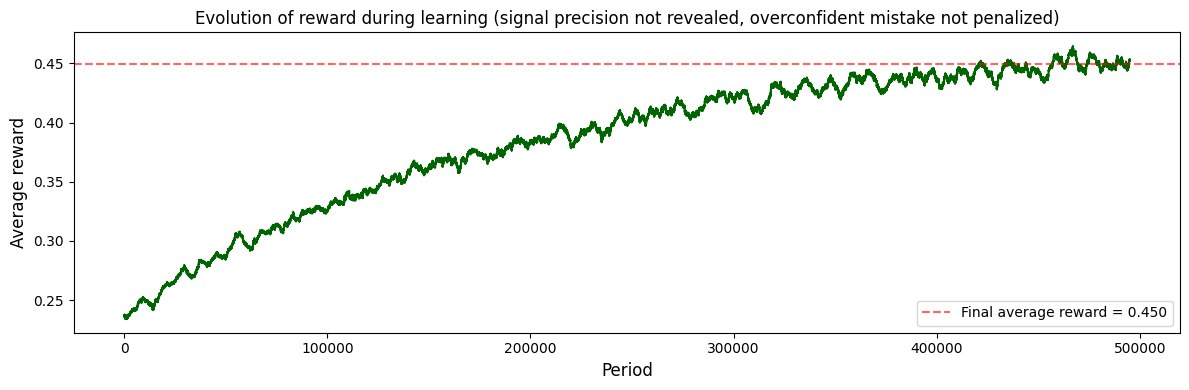

In [ ]:
# Figure 3 : Average reward over time
avg_reward    = np.mean(reward_info, axis=1)
smooth_reward = np.convolve(avg_reward, np.ones(smooth)/smooth, mode='valid')

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(smooth_reward, color='darkgreen', lw=1.5)
ax.axhline(y=np.mean(avg_reward[-50000:]), ls='--', color='red',
           alpha=0.6, label=f'Final average reward = {np.mean(avg_reward[-50000:]):.3f}')
ax.set_xlabel('Period', fontsize=12)
ax.set_ylabel('Average reward', fontsize=12)
ax.set_title('Evolution of reward during learning (signal precision not revealed, overconfident mistake not penalized)', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

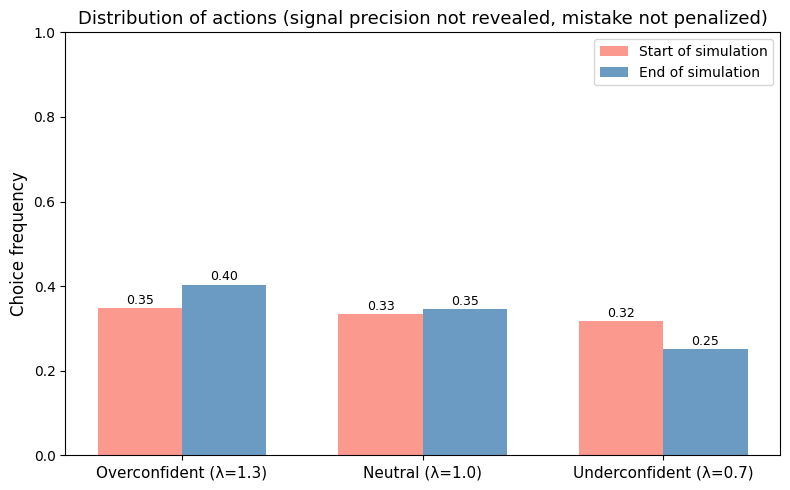

In [ ]:
# Figure 4 : Distribution of chosen actions (start vs end)
T_cut  = criterion_final // 5
T_half = criterion_final // 2

debut_counts = np.bincount(lambda_info[:T_cut].flatten(), minlength=3) / (T_cut * n_episodes)
fin_counts   = np.bincount(lambda_info[T_half:].flatten(), minlength=3) / ((criterion_final - T_half) * n_episodes)

x = np.arange(3)
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, debut_counts, width, label='Start of simulation', color='salmon', alpha=0.8)
bars2 = ax.bar(x + width/2, fin_counts,   width, label='End of simulation',   color='steelblue', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(LAMBDA_NAMES, fontsize=11)
ax.set_ylabel('Choice frequency', fontsize=12)
ax.set_title('Distribution of actions (signal precision not revealed, mistake not penalized)', fontsize=13)
ax.legend(fontsize=10)
ax.set_ylim(0, 1)
for bar in bars1: ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{bar.get_height():.2f}', ha='center', fontsize=9)
for bar in bars2: ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{bar.get_height():.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()